In [1]:
import sys
module_path = '/Users/woodml/Code/XMM_SAS/xmmsas_20230412_1735/lib/python' # or the path to your source code
sys.path.insert(0, module_path)
%env SAS_PATH=/Users/woodml/Code/XMM_SAS/xmmsas_20230412_1735
%env SAS_PATH=$SAS_PATH/config/ftools:$SAS_PATH
from pysas.wrapper import Wrapper as w
import os
import os.path
import glob
import numpy as np
from astropy.io import fits
from astropy.table import Table

from extraction_fcns import extract_lc, extract_spectrum, plot_LC, plot_region, plot_region_om, plot_spectrum, rolling_median

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.collections import PatchCollection
from matplotlib.patches import Circle
from matplotlib import rcParams
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Georgia']
rcParams['font.weight'] = 'bold'
rcParams['axes.labelweight'] = 'bold'
rcParams['axes.linewidth'] = 1

env: SAS_PATH=/Users/woodml/Code/XMM_SAS/xmmsas_20230412_1735
env: SAS_PATH=$SAS_PATH/config/ftools:$SAS_PATH


In [2]:
work_dir = '/Users/woodml/Observing/XMM-Newton/AB_Aur/0671960101/'
sas_file = '/Users/woodml/Observing/XMM-Newton/AB_Aur/0671960101/'

inargs = [f'sas_ccf={sas_file}ccf.cif', f'sas_odf={sas_file}2232_0671960101_SCX00000SUM.SAS', f'workdir={work_dir}']

w('startsas', inargs).run()


startsas - WARNING - Executing /Users/woodml/Code/XMM_SAS/xmmsas_20230412_1735/lib/python/pysas/startsas/startsas.py {'odfid': '', 'workdir': '/Users/woodml/Observing/XMM-Newton/AB_Aur/0671960101/', 'sasfiles': 'yes', 'sas_ccf': '/Users/woodml/Observing/XMM-Newton/AB_Aur/0671960101/ccf.cif', 'sas_odf': '/Users/woodml/Observing/XMM-Newton/AB_Aur/0671960101/2232_0671960101_SCX00000SUM.SAS', 'level': 'ODF', 'cifbuild_opts': '', 'odfingest_opts': ''}




        Starting SAS session
    
        Working directory = /Users/woodml/Observing/XMM-Newton/AB_Aur/0671960101/
    
        
SAS_CCF = /Users/woodml/Observing/XMM-Newton/AB_Aur/0671960101/ccf.cif
SAS_ODF = /Users/woodml/Observing/XMM-Newton/AB_Aur/0671960101/2232_0671960101_SCX00000SUM.SAS


# LC Extraction - EMOS & EPN

In [3]:
# Get Time Limits
print('EMOS 1')
hdul = fits.open('2232_0671960101_EMOS1_S001_ImagingEvts.ds')
e1 = Table(hdul[1].data)
e1.sort('TIME')

print('  Time Start: ', e1['TIME'][0])
print('  Time End:   ', e1['TIME'][-1])

print('EMOS 1')
hdul = fits.open('2232_0671960101_EMOS2_S002_ImagingEvts.ds')
e2 = Table(hdul[1].data)
e2.sort('TIME')

print('  Time Start: ', e2['TIME'][0])
print('  Time End:   ', e2['TIME'][-1])

print('\n\nTime Interval: ', np.ceil(np.max([e1['TIME'][0], e2['TIME'][0]])), '-', np.floor(np.min([e1['TIME'][-1], e2['TIME'][-1]])))

EMOS 1
  Time Start:  445726226.05533797
  Time End:    445828544.8760344
EMOS 1
  Time Start:  445726225.5324148
  Time End:    445828552.4891924


Time Interval:  445726227.0 - 445828544.0


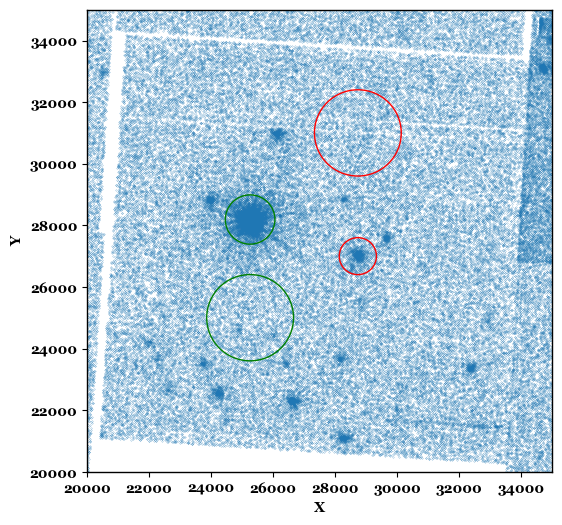

In [4]:
# Plot Image, Determine Extraction Region
event_file   = '2232_0671960101_EMOS1_S001_ImagingEvts.ds'

su_aur = (25260.645, 28188.236)
ab_aur = (28736.144, 26999.234)

hdul = fits.open(event_file)
events = Table(hdul[1].data)

_, ax = plt.subplots(figsize=(6, 6))
plt.scatter(events['X'], events['Y'], marker='.', s=0.1)
p = plt.Circle(su_aur, 800, edgecolor='green', fill=False)
ax.add_artist(p)
p = plt.Circle(ab_aur, 600, edgecolor='red', fill=False)
ax.add_artist(p)
p = plt.Circle((25260.645, 25000.5), 1400, edgecolor='green', fill=False)
ax.add_artist(p)
p = plt.Circle((28736.144, 31000.5), 1400, edgecolor='red', fill=False)
ax.add_artist(p)
plt.xlabel('X')
plt.ylabel('Y')
plt.xlim(20000, 35000)
plt.ylim(20000, 35000)
plt.show()

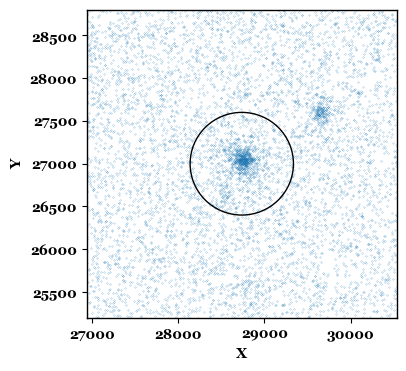



Extracting source LC




Time limits
Executing: 
evselect table='/Users/woodml/Observing/XMM-Newton/AB_Aur/0671960101/2232_0671960101_EMOS1_S001_ImagingEvts.ds' keepfilteroutput='no' withfilteredset='no' filteredset='filtered.fits' destruct='yes' flagcolumn='EVFLAG' flagbit='-1' filtertype='expression' dssblock='' expression='#XMMEA_EMOS1&&(PATTERN<=12)&&((X,Y) IN circle(28736.144,26999.234,600))&&(PI in [200.0:10000.0])' writedss='yes' cleandss='no' updateexposure='yes' filterexposure='yes' blockstocopy='' attributestocopy='' energycolumn='PI' withzcolumn='no' zcolumn='WEIGHT' withzerrorcolumn='no' zerrorcolumn='EWEIGHT' ignorelegallimits='no' withimageset='no' imageset='image.fits' xcolumn='RAWX' ycolumn='RAWY' imagebinning='imageSize' ximagebinsize='1' yimagebinsize='1' squarepixels='no' ximagesize='600' yimagesize='600' withxranges='no' ximagemin='1' ximagemax='640' withyranges='no' yimagemin='1' yimagemax='640' withimagedatatype='no' imagedatatype='Real64' withcelestialcenter='n

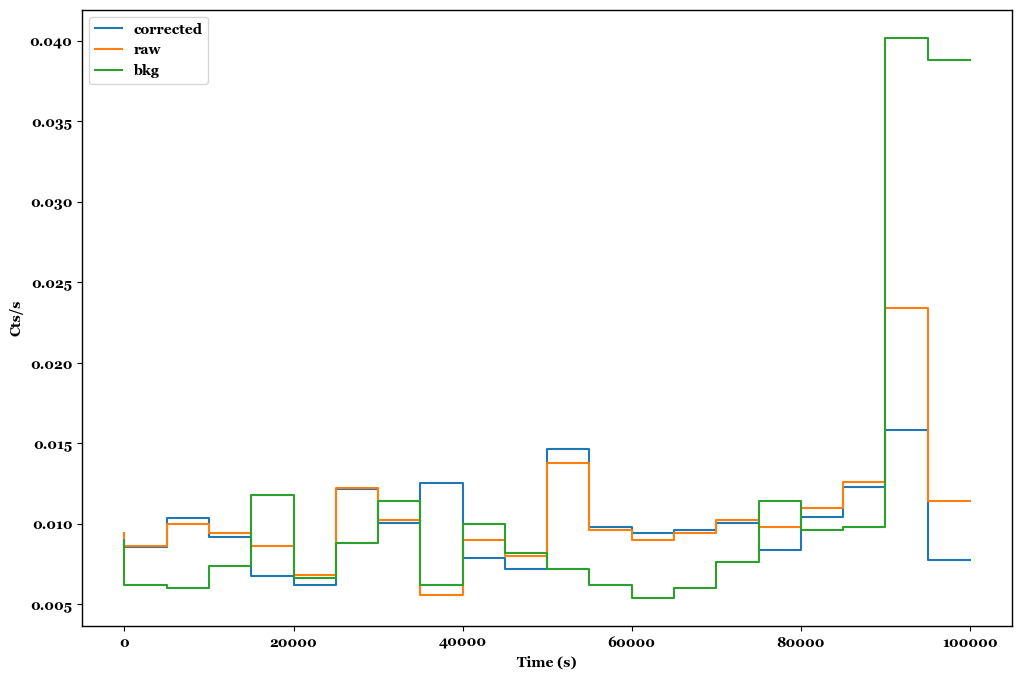

In [5]:
# AB Aur EMOS 1 Extraction

# Prepare
region_1     = (28736.144, 26999.234)
radius       = 600
bkg_1        = (28736.144, 31000.5)
bkg_radius   = 1200

q_flag       = "#XMMEA_EMOS1" # Quality flag for EPIC pn
n_pattern    = 12          # Pattern selection
pi_min       = 200.        # Low energy range eV
pi_max       = 10000.      # High energy range eV
t_min        = 445727565.0
t_max        = 445828820.0
lc_bin       = 5000         # Lightcurve bin in secs

event_file   = '2232_0671960101_EMOS1_S001_ImagingEvts.ds'
source_file  = 'ABAur_EMOS1_lc_5000.lc'
bkg_file     = 'ABAur_EMOS1_bkg_lc_5000.lc' 
final_file   = 'ABAur_EMOS1_final_lc_5000.lc'

# Extract
extract_lc(q_flag, n_pattern, pi_min, pi_max, lc_bin, region_1, radius, bkg_1, bkg_radius, 
           work_dir, event_file, source_file, bkg_file, final_file, time_min=t_min, time_max=t_max)

# Plot

plt.figure(figsize=(12,8))  # Size of figure

plot_LC(plt, final_file, label='corrected')          # Plot corrected light curve
plot_LC(plt, source_file, label='raw')       # Plot source region light curve
plot_LC(plt, bkg_file, label='bkg')       # Plot background region light curve

plt.legend(loc='upper left')
plt.title('')
plt.show()

### EMOS 2

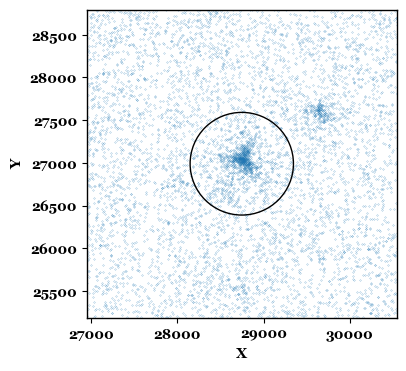



Extracting source LC




Time limits
Executing: 
evselect table='/Users/woodml/Observing/XMM-Newton/AB_Aur/0671960101/2232_0671960101_EMOS2_S002_ImagingEvts.ds' keepfilteroutput='no' withfilteredset='no' filteredset='filtered.fits' destruct='yes' flagcolumn='EVFLAG' flagbit='-1' filtertype='expression' dssblock='' expression='#XMMEA_EMOS2&&(PATTERN<=12)&&((X,Y) IN circle(28747.581,26990.385,600))&&(PI in [200.0:10000.0])' writedss='yes' cleandss='no' updateexposure='yes' filterexposure='yes' blockstocopy='' attributestocopy='' energycolumn='PI' withzcolumn='no' zcolumn='WEIGHT' withzerrorcolumn='no' zerrorcolumn='EWEIGHT' ignorelegallimits='no' withimageset='no' imageset='image.fits' xcolumn='RAWX' ycolumn='RAWY' imagebinning='imageSize' ximagebinsize='1' yimagebinsize='1' squarepixels='no' ximagesize='600' yimagesize='600' withxranges='no' ximagemin='1' ximagemax='640' withyranges='no' yimagemin='1' yimagemax='640' withimagedatatype='no' imagedatatype='Real64' withcelestialcenter='n

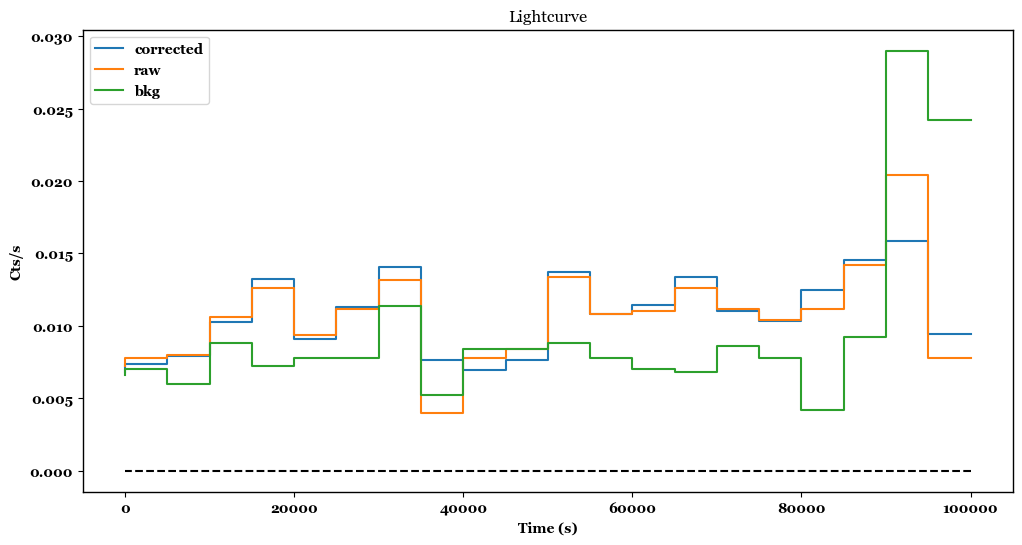

In [6]:
# AB Aur EMOS 2 Extraction

# Prepare
region_2     = (28747.581, 26990.385)
radius       = 600
bkg_2        = (28747.581, 31000.5) 
bkg_radius       = 1200.

q_flag       = "#XMMEA_EMOS2"
n_pattern    = 12          # Pattern selection
pi_min       = 200.        # Low energy range eV
pi_max       = 10000.      # High energy range eV
time_min     = 445727565.0
time_max     = 445828820.0
lc_bin       = 5000         # Lightcurve bin in secs

event_file   = '2232_0671960101_EMOS2_S002_ImagingEvts.ds'
source_file  = 'ABAur_EMOS2_lc_5000.lc'
bkg_file     = 'ABAur_EMOS2_bkg_lc_5000.lc' 
final_file   = 'ABAur_EMOS2_final_lc_5000.lc'

# Extract
extract_lc(q_flag, n_pattern, pi_min, pi_max, lc_bin, region_2, radius, bkg_2, 
               bkg_radius, work_dir, event_file, source_file, bkg_file, final_file, time_min, time_max,)

# Plot
plt.figure(figsize=(12,6))  # Size of figure
plot_LC(plt, final_file, label='corrected')          # Plot corrected light curve
plot_LC(plt, source_file, label='raw')       # Plot source region light curve
plot_LC(plt, bkg_file, label='bkg')       # Plot background region light curve
plt.hlines(0,100000, 0, 'k','--', zorder=0)
plt.legend(loc='upper left')
plt.show()

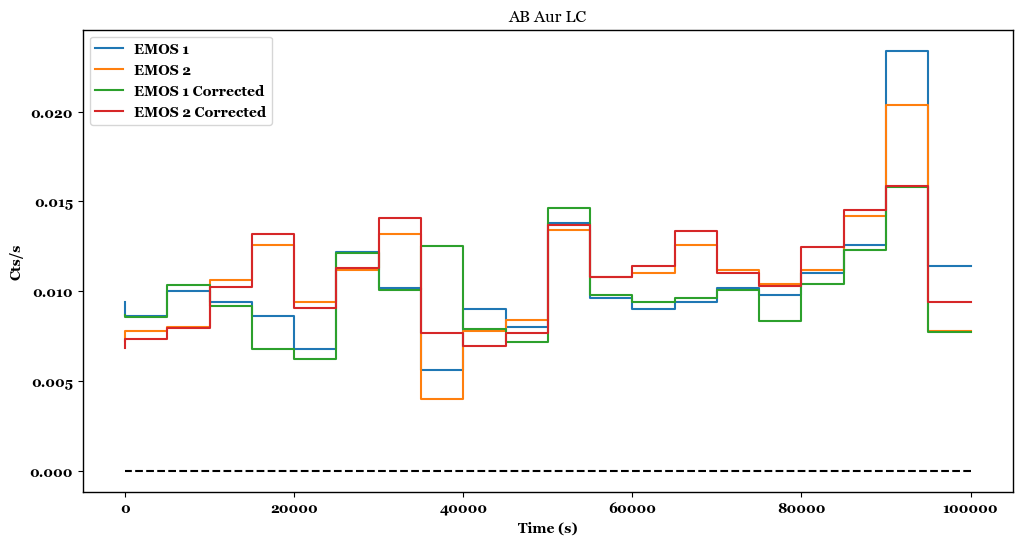

In [7]:
# Plot both AB Aur EMOS
plt.figure(figsize=(12,6))  # Size of figure
plot_LC(plt, 'ABAur_EMOS1_lc_5000.lc', label='EMOS 1')
plot_LC(plt, 'ABAur_EMOS2_lc_5000.lc', label='EMOS 2')
plot_LC(plt, 'ABAur_EMOS1_final_lc_5000.lc', label='EMOS 1 Corrected')
plot_LC(plt, 'ABAur_EMOS2_final_lc_5000.lc', label='EMOS 2 Corrected')
plt.hlines(0,100000, 0, 'k','--', zorder=0)
plt.title('AB Aur LC')
plt.legend(loc='upper left')
plt.show()

### EPN

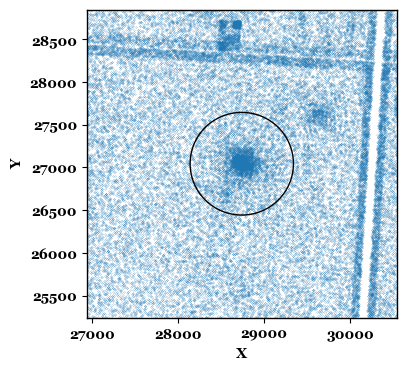



Extracting source LC




Time limits
Executing: 
evselect table='/Users/woodml/Observing/XMM-Newton/AB_Aur/0671960101/2232_0671960101_EPN_S003_ImagingEvts.ds' keepfilteroutput='no' withfilteredset='no' filteredset='filtered.fits' destruct='yes' flagcolumn='EVFLAG' flagbit='-1' filtertype='expression' dssblock='' expression='#XMMEA_EP&&(PATTERN<=4)&&((X,Y) IN circle(28741.627,27041.752,600.0))&&(PI in [200.0:10000.0])' writedss='yes' cleandss='no' updateexposure='yes' filterexposure='yes' blockstocopy='' attributestocopy='' energycolumn='PI' withzcolumn='no' zcolumn='WEIGHT' withzerrorcolumn='no' zerrorcolumn='EWEIGHT' ignorelegallimits='no' withimageset='no' imageset='image.fits' xcolumn='RAWX' ycolumn='RAWY' imagebinning='imageSize' ximagebinsize='1' yimagebinsize='1' squarepixels='no' ximagesize='600' yimagesize='600' withxranges='no' ximagemin='1' ximagemax='640' withyranges='no' yimagemin='1' yimagemax='640' withimagedatatype='no' imagedatatype='Real64' withcelestialcenter='no' r

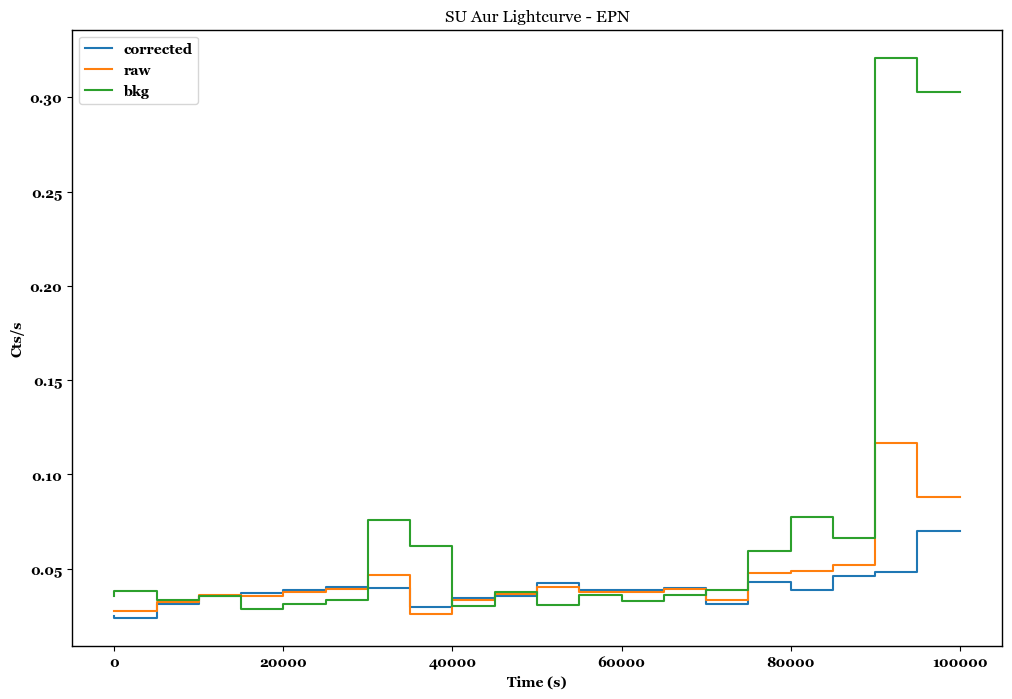

In [8]:
# EPN
# Prepare
# - - - - - - - - - - - - - - - - - - -
AB_Aur_region = (28741.627, 27041.752)
radius        = 600.
AB_Aur_bkg    = (28741.627, 24500.5)
bkg_radius    = 1200

q_flag        = "#XMMEA_EP" # Quality flag for EPIC pn
n_pattern     = 4          # Pattern selection
pn_pi_min     = 200.        # Low energy range eV
pn_pi_max     = 10000.      # High energy range eV
lc_bin        = 5000         # Lightcurve bin in secs

event_file    = '2232_0671960101_EPN_S003_ImagingEvts.ds'
source_file   = 'ABAur_PN_lc_5000.lc'               
bkg_file      = 'ABAur_EPN_bkg_lc_5000.lc'
final_file    = 'ABAur_EPN_final_lc_5000.lc'

# Extract
# - - - - - - - - - - - - - - - - - - -
extract_lc(q_flag, n_pattern, pi_min, pi_max, lc_bin, AB_Aur_region, radius, AB_Aur_bkg, 
               bkg_radius, work_dir, event_file, source_file, bkg_file, final_file, time_min, time_max)

# Plot
# - - - - - - - - - - - - - - - - - - -
plt.figure(figsize=(12,8))  # Size of figure

plot_LC(plt, final_file, label='corrected')          # Plot corrected light curve
plot_LC(plt, source_file, label='raw')       # Plot source region light curve
plot_LC(plt, bkg_file, label='bkg')       # Plot background region light curve

plt.legend(loc='upper left')
plt.title('SU Aur Lightcurve - EPN')
plt.show()

### Combine EMOS 1, EMOS 2, EPN

In [9]:
# Combine LCs
# - - - - - - - - - - - - - - - - 

combined_file = work_dir+'ABAur_combined_5000.lc'   # Name of the output corrected lightcurve

# SAS Command
cmd        = "elcbuild" # SAS task to be executed                  

# Arguments of SAS Command
inargs     = [f'sets=ABAur_EMOS1_final_lc_5000.lc ABAur_EMOS2_final_lc_5000.lc ABAur_EPN_final_lc_5000.lc',
             f'outset={combined_file}']

w(cmd, inargs).run()

Executing: 
elcbuild sets='ABAur_EMOS1_final_lc_5000.lc ABAur_EMOS2_final_lc_5000.lc ABAur_EPN_final_lc_5000.lc' outset='/Users/woodml/Observing/XMM-Newton/AB_Aur/0671960101/ABAur_combined_5000.lc' 
elcbuild:- Executing (routine): elcbuild sets='ABAur_EMOS1_final_lc_5000.lc ABAur_EMOS2_final_lc_5000.lc ABAur_EPN_final_lc_5000.lc' outset=/Users/woodml/Observing/XMM-Newton/AB_Aur/0671960101/ABAur_combined_5000.lc  -w 1 -V 4
elcbuild:- elcbuild (elcbuild-1.10)  [xmmsas_20230412_1735-21.0.0] started:  2024-10-22T14:49:07.000
elcbuild:- elcbuild (elcbuild-1.10)  [xmmsas_20230412_1735-21.0.0] ended:    2024-10-22T14:49:07.000


Filename: /Users/woodml/Observing/XMM-Newton/AB_Aur/0671960101/ABAur_combined_5000.lc
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      19   ()      
  1  RATE          1 BinTableHDU     81   21R x 5C   [3E, 3E, 3E, 3E, 3E]   


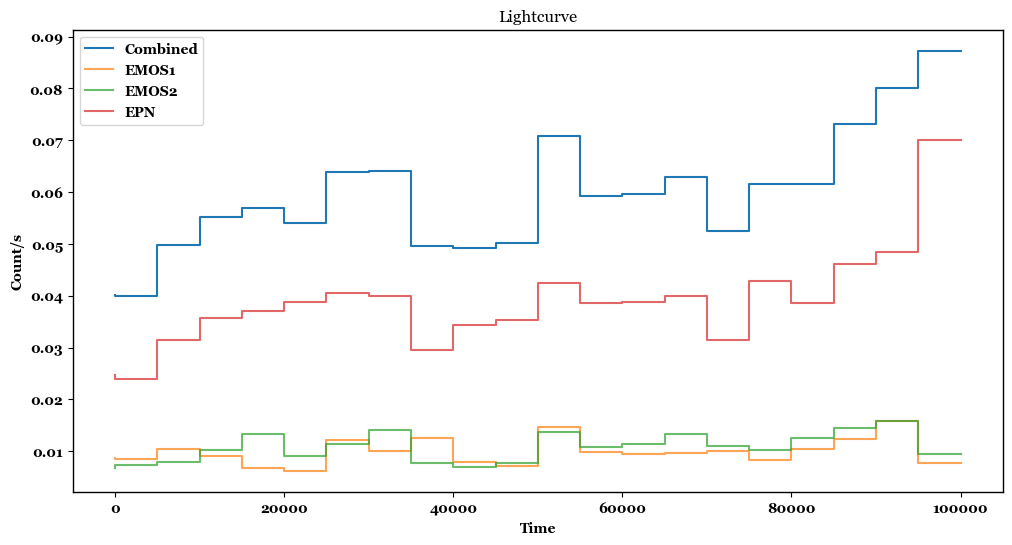

In [10]:
# Plot combined LC
hdul = fits.open(combined_file)
hdul.info()

lc = Table(hdul[1].data)

x = np.arange(hdul[1].header['TSTART'], hdul[1].header['TSTOP'], hdul[1].header['TIMEDEL'])-hdul[1].header['TSTART']

plt.figure(figsize=(12,6))
plt.step(x, np.sum(lc['RATE'], 1), label='Combined')
plot_LC(plt, 'ABAur_EMOS1_final_lc_5000.lc', label='EMOS1', alpha=0.7)
plot_LC(plt, 'ABAur_EMOS2_final_lc_5000.lc', label='EMOS2', alpha=0.7)
plot_LC(plt, 'ABAur_EPN_final_lc_5000.lc', label='EPN', alpha=0.7)
plt.xlabel('Time')
plt.ylabel('Count/s')
plt.legend()
plt.show()

## Soft and Hard LCs

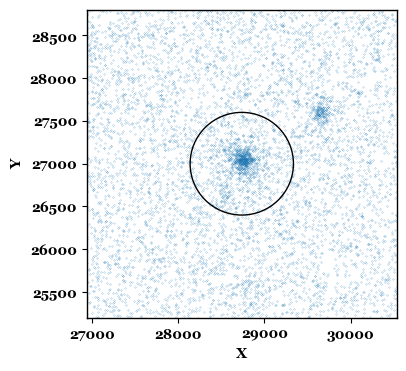



Extracting source LC




Time limits
Executing: 
evselect table='/Users/woodml/Observing/XMM-Newton/AB_Aur/0671960101/2232_0671960101_EMOS1_S001_ImagingEvts.ds' keepfilteroutput='no' withfilteredset='no' filteredset='filtered.fits' destruct='yes' flagcolumn='EVFLAG' flagbit='-1' filtertype='expression' dssblock='' expression='#XMMEA_EMOS1&&(PATTERN<=12)&&((X,Y) IN circle(28736.144,26999.234,600))&&(PI in [200.0:1500])' writedss='yes' cleandss='no' updateexposure='yes' filterexposure='yes' blockstocopy='' attributestocopy='' energycolumn='PI' withzcolumn='no' zcolumn='WEIGHT' withzerrorcolumn='no' zerrorcolumn='EWEIGHT' ignorelegallimits='no' withimageset='no' imageset='image.fits' xcolumn='RAWX' ycolumn='RAWY' imagebinning='imageSize' ximagebinsize='1' yimagebinsize='1' squarepixels='no' ximagesize='600' yimagesize='600' withxranges='no' ximagemin='1' ximagemax='640' withyranges='no' yimagemin='1' yimagemax='640' withimagedatatype='no' imagedatatype='Real64' withcelestialcenter='no' 

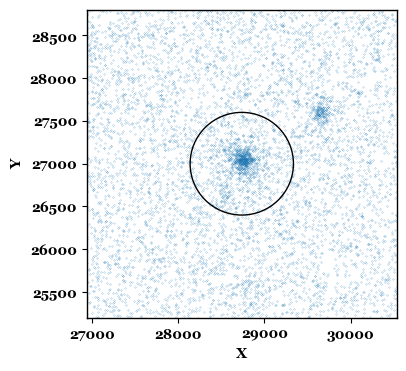



Extracting source LC




Time limits
Executing: 
evselect table='/Users/woodml/Observing/XMM-Newton/AB_Aur/0671960101/2232_0671960101_EMOS1_S001_ImagingEvts.ds' keepfilteroutput='no' withfilteredset='no' filteredset='filtered.fits' destruct='yes' flagcolumn='EVFLAG' flagbit='-1' filtertype='expression' dssblock='' expression='#XMMEA_EMOS1&&(PATTERN<=12)&&((X,Y) IN circle(28736.144,26999.234,600))&&(PI in [1500:10000.0])' writedss='yes' cleandss='no' updateexposure='yes' filterexposure='yes' blockstocopy='' attributestocopy='' energycolumn='PI' withzcolumn='no' zcolumn='WEIGHT' withzerrorcolumn='no' zerrorcolumn='EWEIGHT' ignorelegallimits='no' withimageset='no' imageset='image.fits' xcolumn='RAWX' ycolumn='RAWY' imagebinning='imageSize' ximagebinsize='1' yimagebinsize='1' squarepixels='no' ximagesize='600' yimagesize='600' withxranges='no' ximagemin='1' ximagemax='640' withyranges='no' yimagemin='1' yimagemax='640' withimagedatatype='no' imagedatatype='Real64' withcelestialcenter='no

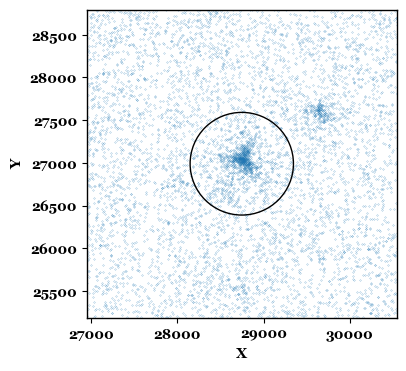



Extracting source LC




Time limits
Executing: 
evselect table='/Users/woodml/Observing/XMM-Newton/AB_Aur/0671960101/2232_0671960101_EMOS2_S002_ImagingEvts.ds' keepfilteroutput='no' withfilteredset='no' filteredset='filtered.fits' destruct='yes' flagcolumn='EVFLAG' flagbit='-1' filtertype='expression' dssblock='' expression='#XMMEA_EMOS2&&(PATTERN<=12)&&((X,Y) IN circle(28747.581,26990.385,600))&&(PI in [200.0:1500])' writedss='yes' cleandss='no' updateexposure='yes' filterexposure='yes' blockstocopy='' attributestocopy='' energycolumn='PI' withzcolumn='no' zcolumn='WEIGHT' withzerrorcolumn='no' zerrorcolumn='EWEIGHT' ignorelegallimits='no' withimageset='no' imageset='image.fits' xcolumn='RAWX' ycolumn='RAWY' imagebinning='imageSize' ximagebinsize='1' yimagebinsize='1' squarepixels='no' ximagesize='600' yimagesize='600' withxranges='no' ximagemin='1' ximagemax='640' withyranges='no' yimagemin='1' yimagemax='640' withimagedatatype='no' imagedatatype='Real64' withcelestialcenter='no' 

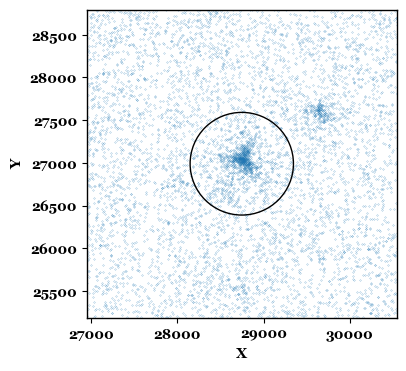



Extracting source LC




Time limits
Executing: 
evselect table='/Users/woodml/Observing/XMM-Newton/AB_Aur/0671960101/2232_0671960101_EMOS2_S002_ImagingEvts.ds' keepfilteroutput='no' withfilteredset='no' filteredset='filtered.fits' destruct='yes' flagcolumn='EVFLAG' flagbit='-1' filtertype='expression' dssblock='' expression='#XMMEA_EMOS2&&(PATTERN<=12)&&((X,Y) IN circle(28747.581,26990.385,600))&&(PI in [1500:10000.0])' writedss='yes' cleandss='no' updateexposure='yes' filterexposure='yes' blockstocopy='' attributestocopy='' energycolumn='PI' withzcolumn='no' zcolumn='WEIGHT' withzerrorcolumn='no' zerrorcolumn='EWEIGHT' ignorelegallimits='no' withimageset='no' imageset='image.fits' xcolumn='RAWX' ycolumn='RAWY' imagebinning='imageSize' ximagebinsize='1' yimagebinsize='1' squarepixels='no' ximagesize='600' yimagesize='600' withxranges='no' ximagemin='1' ximagemax='640' withyranges='no' yimagemin='1' yimagemax='640' withimagedatatype='no' imagedatatype='Real64' withcelestialcenter='no

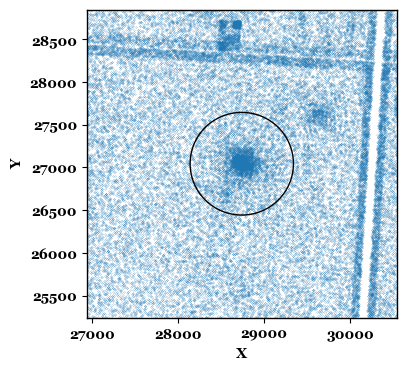



Extracting source LC




Time limits
Executing: 
evselect table='/Users/woodml/Observing/XMM-Newton/AB_Aur/0671960101/2232_0671960101_EPN_S003_ImagingEvts.ds' keepfilteroutput='no' withfilteredset='no' filteredset='filtered.fits' destruct='yes' flagcolumn='EVFLAG' flagbit='-1' filtertype='expression' dssblock='' expression='#XMMEA_EP&&(PATTERN<=4)&&((X,Y) IN circle(28741.627,27041.752,600.0))&&(PI in [200.0:1500])' writedss='yes' cleandss='no' updateexposure='yes' filterexposure='yes' blockstocopy='' attributestocopy='' energycolumn='PI' withzcolumn='no' zcolumn='WEIGHT' withzerrorcolumn='no' zerrorcolumn='EWEIGHT' ignorelegallimits='no' withimageset='no' imageset='image.fits' xcolumn='RAWX' ycolumn='RAWY' imagebinning='imageSize' ximagebinsize='1' yimagebinsize='1' squarepixels='no' ximagesize='600' yimagesize='600' withxranges='no' ximagemin='1' ximagemax='640' withyranges='no' yimagemin='1' yimagemax='640' withimagedatatype='no' imagedatatype='Real64' withcelestialcenter='no' raim

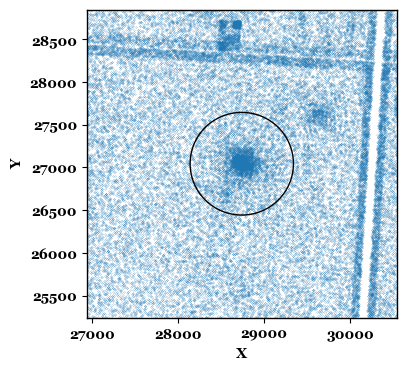



Extracting source LC




Time limits
Executing: 
evselect table='/Users/woodml/Observing/XMM-Newton/AB_Aur/0671960101/2232_0671960101_EPN_S003_ImagingEvts.ds' keepfilteroutput='no' withfilteredset='no' filteredset='filtered.fits' destruct='yes' flagcolumn='EVFLAG' flagbit='-1' filtertype='expression' dssblock='' expression='#XMMEA_EP&&(PATTERN<=4)&&((X,Y) IN circle(28741.627,27041.752,600.0))&&(PI in [1500:10000.0])' writedss='yes' cleandss='no' updateexposure='yes' filterexposure='yes' blockstocopy='' attributestocopy='' energycolumn='PI' withzcolumn='no' zcolumn='WEIGHT' withzerrorcolumn='no' zerrorcolumn='EWEIGHT' ignorelegallimits='no' withimageset='no' imageset='image.fits' xcolumn='RAWX' ycolumn='RAWY' imagebinning='imageSize' ximagebinsize='1' yimagebinsize='1' squarepixels='no' ximagesize='600' yimagesize='600' withxranges='no' ximagemin='1' ximagemax='640' withyranges='no' yimagemin='1' yimagemax='640' withimagedatatype='no' imagedatatype='Real64' withcelestialcenter='no' ra

epiclccorr::evselect:- Executing (routine): evselect table=/Users/woodml/Observing/XMM-Newton/0671960101/2232_0671960101_EPN_S003_ImagingEvts.ds:EVENTS filteredset=filtered.fits withfilteredset=no keepfilteroutput=no flagcolumn=EVFLAG flagbit=-1 destruct=yes dssblock='' expression='( ( CCDNR in [1] && gti(/Users/woodml/Observing/XMM-Newton/0671960101/SUAur_EPN_lc_hard.lc:STDGTI01,TIME) && FLAG&0xcfa0000==0 && PATTERN in (:4] && region(/Users/woodml/Observing/XMM-Newton/0671960101/SUAur_EPN_lc_hard.lc:REG00105,X,Y) && PI in [1500:10000] ) || ( CCDNR in [2] && gti(/Users/woodml/Observing/XMM-Newton/0671960101/SUAur_EPN_lc_hard.lc:STDGTI02,TIME) && FLAG&0xcfa0000==0 && PATTERN in (:4] && region(/Users/woodml/Observing/XMM-Newton/0671960101/SUAur_EPN_lc_hard.lc:REG00105,X,Y) && PI in [1500:10000] ) || ( CCDNR in [3] && gti(/Users/woodml/Observing/XMM-Newton/0671960101/SUAur_EPN_lc_hard.lc:STDGTI03,TIME) && FLAG&0xcfa0000==0 && PATTERN in (:4] && region(/Users/woodml/Observing/XMM-Newton/06

epiclccorr::evselect:- Executing (routine): evselect table=/Users/woodml/Observing/XMM-Newton/0671960101/2232_0671960101_EPN_S003_ImagingEvts.ds:EVENTS filteredset=filtered.fits withfilteredset=no keepfilteroutput=no flagcolumn=EVFLAG flagbit=-1 destruct=yes dssblock='' expression='( ( CCDNR in [1] && gti(/Users/woodml/Observing/XMM-Newton/0671960101/SUAur_EPN_lc_hard.lc:STDGTI01,TIME) && FLAG&0xcfa0000==0 && PATTERN in (:4] && region(/Users/woodml/Observing/XMM-Newton/0671960101/SUAur_EPN_lc_hard.lc:REG00105,X,Y) && PI in [1500:10000] ) || ( CCDNR in [2] && gti(/Users/woodml/Observing/XMM-Newton/0671960101/SUAur_EPN_lc_hard.lc:STDGTI02,TIME) && FLAG&0xcfa0000==0 && PATTERN in (:4] && region(/Users/woodml/Observing/XMM-Newton/0671960101/SUAur_EPN_lc_hard.lc:REG00105,X,Y) && PI in [1500:10000] ) || ( CCDNR in [3] && gti(/Users/woodml/Observing/XMM-Newton/0671960101/SUAur_EPN_lc_hard.lc:STDGTI03,TIME) && FLAG&0xcfa0000==0 && PATTERN in (:4] && region(/Users/woodml/Observing/XMM-Newton/06

Making file temp_badcol.ds
epiclccorr::arfgen:- WCS info for the columns temp_badcol.ds:BADPIX01:RAWX and temp_badcol.ds:BADPIX01:RAWX is either non-existent or incomplete. Assuming a 1:1 mapping
epiclccorr::arfgen:- Writing energy data into dataset .. 
epiclccorr::arfgen:- Calculating Area curve ...
epiclccorr::arfgen:- Calculating Area curve ...50.5 2067 15997.5
epiclccorr::arfgen:- Executing (routine): attcalc eventset=rawpixellist.ds:EVENTS fixedra=73.986917 fixeddec=30.535611 fixedposangle=266.395294 attitudelabel=fixed nominalra=73.986917 nominaldec=30.535611 setpnttouser=no refpointlabel=user atthkset=atthk.dat withatthkset=no withmedianpnt=yes calctlmax=no imagesize=0.36  -w 1 -V 4
epiclccorr::arfgen:- attcalc (attcalc-4.39)  [xmmsas_20230412_1735-21.0.0] started:  2023-12-11T20:08:47.000
epiclccorr::arfgen:- attcalc (attcalc-4.39)  [xmmsas_20230412_1735-21.0.0] ended:    2023-12-11T20:08:47.000
epiclccorr::arfgen:- Bad pixel & chip gap fraction: ~97.91628487 %
epiclccorr::arfg

epiclccorr::arfgen:- Executing (routine): arfgen spectrumset=/var/tmp/tmp.5.yduRZYspectrum_ccd7.fits rmfset=response.ds withrmfset=no arfset=src_ancillary.ds detmaptype=flat detmaparray=detmapfile.ds: detxoffset=1200 detyoffset=1200 withdetbounds=no detxbins=5 detybins=5 withdetbins=no psfenergy=2 filterdss=yes filteredset=filteredpixellist.ds withfilteredset=no sourcecoords=eqpos sourcex=0 sourcey=0 withsourcepos=no extendedsource=no modeleffarea=yes modelquantumeff=yes modelfiltertrans=yes modelcontamination=yes modelee=yes modelootcorr=yes applyxcaladjustment=no applyabsfluxcorr=no eegridfactor=100 withbadpixcorr=yes badpixlocation=/Users/woodml/Observing/XMM-Newton/0671960101/2232_0671960101_EPN_S003_ImagingEvts.ds psfmodel=ELLBETA badpixelresolution=2 withbadpixres=no badpixmaptype=flat setbackscale=yes keeparfset=yes useodfatt=no ignoreoutoffov=yes crossreg_spectrumset='' crossregionarf=no  -w 1 -V 4
epiclccorr::arfgen:- arfgen (arfgen-1.104)  [xmmsas_20230412_1735-21.0.0] starte

...

epiclccorr::evselect:- Executing (routine): evselect table=/Users/woodml/Observing/XMM-Newton/0671960101/2232_0671960101_EPN_S003_ImagingEvts.ds:EVENTS filteredset=filtered.fits withfilteredset=no keepfilteroutput=no flagcolumn=EVFLAG flagbit=-1 destruct=yes dssblock='' expression='( ( CCDNR in [1] && gti(/Users/woodml/Observing/XMM-Newton/0671960101/SUAur_EPN_bkg_lc_hard.lc:STDGTI01,TIME) && FLAG&0xcfa0000==0 && PATTERN in (:4] && region(/Users/woodml/Observing/XMM-Newton/0671960101/SUAur_EPN_bkg_lc_hard.lc:REG00105,X,Y) && PI in [1500:10000] ) || ( CCDNR in [2] && gti(/Users/woodml/Observing/XMM-Newton/0671960101/SUAur_EPN_bkg_lc_hard.lc:STDGTI02,TIME) && FLAG&0xcfa0000==0 && PATTERN in (:4] && region(/Users/woodml/Observing/XMM-Newton/0671960101/SUAur_EPN_bkg_lc_hard.lc:REG00105,X,Y) && PI in [1500:10000] ) || ( CCDNR in [3] && gti(/Users/woodml/Observing/XMM-Newton/0671960101/SUAur_EPN_bkg_lc_hard.lc:STDGTI03,TIME) && FLAG&0xcfa0000==0 && PATTERN in (:4] && region(/Users/woodml/Obs

Making file temp_badcol.ds
epiclccorr::arfgen:- WCS info for the columns temp_badcol.ds:BADPIX01:RAWX and temp_badcol.ds:BADPIX01:RAWX is either non-existent or incomplete. Assuming a 1:1 mapping
epiclccorr::arfgen:- Writing energy data into dataset .. 
epiclccorr::arfgen:- Calculating Area curve ...
epiclccorr::arfgen:- Calculating Area curve ...50.5 2067 15997.5
epiclccorr::arfgen:- Executing (routine): attcalc eventset=rawpixellist.ds:EVENTS fixedra=73.986917 fixeddec=30.535611 fixedposangle=266.395294 attitudelabel=fixed nominalra=73.986917 nominaldec=30.535611 setpnttouser=no refpointlabel=user atthkset=atthk.dat withatthkset=no withmedianpnt=yes calctlmax=no imagesize=0.36  -w 1 -V 4
epiclccorr::arfgen:- attcalc (attcalc-4.39)  [xmmsas_20230412_1735-21.0.0] started:  2023-12-11T20:10:01.000
epiclccorr::arfgen:- attcalc (attcalc-4.39)  [xmmsas_20230412_1735-21.0.0] ended:    2023-12-11T20:10:01.000
epiclccorr::arfgen:- Bad pixel & chip gap fraction: ~91.28582803 %
epiclccorr::arfg

epiclccorr:- Events already randomized...
epiclccorr:- closing data set /Users/woodml/Observing/XMM-Newton/0671960101/2232_0671960101_EPN_S003_ImagingEvts.ds
epiclccorr:- Exposure Correction Done.
epiclccorr:- Doing Exposure and Dead Time Correction: /Users/woodml/Observing/XMM-Newton/0671960101/2232_0671960101_EPN_S003_ImagingEvts.ds:EXPOSU04
epiclccorr:- Events already randomized...
epiclccorr:- closing data set /Users/woodml/Observing/XMM-Newton/0671960101/2232_0671960101_EPN_S003_ImagingEvts.ds
epiclccorr:- Exposure Correction Done.
epiclccorr:- Done.
epiclccorr:- Calculating spectrum...
epiclccorr:- Executing (invoked): evselect table=/Users/woodml/Observing/XMM-Newton/0671960101/2232_0671960101_EPN_S003_ImagingEvts.ds:EVENTS filteredset=filtered.fits withfilteredset=no keepfilteroutput=no flagcolumn=EVFLAG flagbit=-1 destruct=yes dssblock='' expression='( CCDNR in [1] && gti(/Users/woodml/Observing/XMM-Newton/0671960101/SUAur_EPN_bkg_lc_hard.lc:STDGTI01,TIME) && FLAG&0xcfa0000==0

epiclccorr::evselect:- selected 2023 rows from the input table.
** epiclccorr::evselect: warning (NonStandardSpectrum), The standard PI channel range for PN is 0-20479. Detector matrices can not be created for this spectrum and spectral fitting will not be possible.
epiclccorr::evselect:- evselect (evselect-3.71.2)  [xmmsas_20230412_1735-21.0.0] ended:    2023-12-11T20:10:28.000
epiclccorr:- evselect (evselect-3.71.2)  [xmmsas_20230412_1735-21.0.0] ended:    2023-12-11T20:10:28.000
epiclccorr:- Done.
epiclccorr:- Calculating arfgen...
epiclccorr:- Executing (invoked): arfgen spectrumset=spectrum_SUAur_EPN_bkg_lc_hard.lc rmfset=response.ds withrmfset=no arfset=bkg_ancillary.ds detmaptype=flat detmaparray=detmapfile.ds: detxoffset=1200 detyoffset=1200 withdetbounds=no detxbins=5 detybins=5 withdetbins=no psfenergy=2 filterdss=yes filteredset=filteredpixellist.ds withfilteredset=no sourcecoords=eqpos sourcex=0 sourcey=0 withsourcepos=no extendedsource=yes modeleffarea=yes modelquantumeff=

epiclccorr::arfgen:- Executing (routine): attcalc eventset=rawpixellist.ds:EVENTS fixedra=73.986917 fixeddec=30.535611 fixedposangle=266.395294 attitudelabel=fixed nominalra=73.986917 nominaldec=30.535611 setpnttouser=no refpointlabel=user atthkset=atthk.dat withatthkset=no withmedianpnt=yes calctlmax=no imagesize=0.36  -w 1 -V 4
epiclccorr::arfgen:- attcalc (attcalc-4.39)  [xmmsas_20230412_1735-21.0.0] started:  2023-12-11T20:10:30.000
epiclccorr::arfgen:- attcalc (attcalc-4.39)  [xmmsas_20230412_1735-21.0.0] ended:    2023-12-11T20:10:30.000
epiclccorr::arfgen:- Executing (routine): attcalc eventset=rawpixellist.ds:EVENTS fixedra=73.986917 fixeddec=30.535611 fixedposangle=266.395294 attitudelabel=fixed nominalra=73.986917 nominaldec=30.535611 setpnttouser=no refpointlabel=user atthkset=atthk.dat withatthkset=no withmedianpnt=yes calctlmax=no imagesize=0.36  -w 1 -V 4
epiclccorr::arfgen:- attcalc (attcalc-4.39)  [xmmsas_20230412_1735-21.0.0] started:  2023-12-11T20:10:30.000
epiclccor

In [11]:
# SU Aur compare soft and hard LC
limit = 1500
# EMOS 1
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# Soft
# - - - - - - - - - - -
region_1     = (28736.144, 26999.234)
radius       = 600
bkg_1        = (28736.144, 31000.5)
bkg_radius   = 1200

q_flag       = "#XMMEA_EMOS1" # Quality flag for EPIC pn
n_pattern    = 12             # Pattern selection
pi_min       = 200.           # Low energy range eV
pi_max       = limit          # High energy range eV
time_min     = 445727565.0
time_max     = 445828820.0
lc_bin       = 5000         # Lightcurve bin in secs

event_file  = '2232_0671960101_EMOS1_S001_ImagingEvts.ds'
source_file = 'ABAur_EMOS1_lc_soft_5000.lc'
bkg_file    = 'ABAur_EMOS1_bkg_lc_soft_5000.lc'
final_file  = 'ABAur_EMOS1_final_lc_soft_5000.lc'

extract_lc(q_flag, n_pattern, pi_min, pi_max, lc_bin, region_1, radius, bkg_1, 
               bkg_radius, work_dir, event_file, source_file, bkg_file, final_file, time_min, time_max)

# Hard
# - - - - - - - - - - -
pi_min       = limit          # Low energy range eV
pi_max       = 10000.         # High energy range eV
# others same as above

event_file  = '2232_0671960101_EMOS1_S001_ImagingEvts.ds'
source_file = 'ABAur_EMOS1_lc_hard_5000.lc'
bkg_file    = 'ABAur_EMOS1_bkg_lc_hard_5000.lc'
final_file  = 'ABAur_EMOS1_final_lc_hard_5000.lc'

extract_lc(q_flag, n_pattern, pi_min, pi_max, lc_bin, region_1, radius, bkg_1, 
               bkg_radius, work_dir, event_file, source_file, bkg_file, final_file, time_min, time_max)

# EMOS 2
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# Soft
# - - - - - - - - - - -
region_2     = (28747.581, 26990.385)
radius       = 600
bkg_2        = (28747.581, 31000.5) 
bkg_radius       = 1200.

q_flag       = "#XMMEA_EMOS2" # Quality flag for EPIC pn
n_pattern    = 12             # Pattern selection
pi_min       = 200.           # Low energy range eV
pi_max       = limit          # High energy range eV
time_min     = 445727565.0
time_max     = 445828820.0

event_file  = '2232_0671960101_EMOS2_S002_ImagingEvts.ds'
source_file = 'ABAur_EMOS2_lc_soft_5000.lc'
bkg_file    = 'ABAur_EMOS2_bkg_lc_soft_5000.lc'
final_file  = 'ABAur_EMOS2_final_lc_soft_5000.lc'

extract_lc(q_flag, n_pattern, pi_min, pi_max, lc_bin, region_2, radius, bkg_2, 
               bkg_radius, work_dir, event_file, source_file, bkg_file, final_file, time_min, time_max)

# Hard
# - - - - - - - - - - -
pi_min       = limit          # Low energy range eV
pi_max       = 10000.         # High energy range eV
# others same as above

event_file  = '2232_0671960101_EMOS2_S002_ImagingEvts.ds'
source_file = 'ABAur_EMOS2_lc_hard_5000.lc'
bkg_file    = 'ABAur_EMOS2_bkg_lc_hard_5000.lc'
final_file  = 'ABAur_EMOS2_final_lc_hard_5000.lc'

extract_lc(q_flag, n_pattern, pi_min, pi_max, lc_bin, region_2, radius, bkg_2, 
               bkg_radius, work_dir, event_file, source_file, bkg_file, final_file, time_min, time_max)

# EPN
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# Soft
# - - - - - - - - - - -

region_pn   = (28741.627, 27041.752)
radius      = 600.
bkg_pn      = (28741.627, 24500.5)
bkg_radius  = 1200

q_flag       = "#XMMEA_EP" # Quality flag for EPIC pn
n_pattern    = 4             # Pattern selection
pi_min       = 200.           # Low energy range eV
pi_max       = limit          # High energy range eV
time_min     = 445727565.0
time_max     = 445828820.0

event_file  = '2232_0671960101_EPN_S003_ImagingEvts.ds'
source_file = 'ABAur_EPN_lc_soft_5000.lc'
bkg_file    = 'ABAur_EPN_bkg_lc_soft_5000.lc'
final_file  = 'ABAur_EPN_final_lc_soft_5000.lc'

extract_lc(q_flag, n_pattern, pi_min, pi_max, lc_bin, region_pn, radius, bkg_pn, 
               bkg_radius, work_dir, event_file, source_file, bkg_file, final_file, time_min, time_max)

# Hard
# - - - - - - - - - - -
pi_min       = limit          # Low energy range eV
pi_max       = 10000.         # High energy range eV
# others same as above

event_file  = '2232_0671960101_EPN_S003_ImagingEvts.ds'
source_file = 'ABAur_EPN_lc_hard_5000.lc'
bkg_file    = 'ABAur_EPN_bkg_lc_hard_5000.lc'
final_file  = 'ABAur_EPN_final_lc_hard_5000.lc'

extract_lc(q_flag, n_pattern, pi_min, pi_max, lc_bin, region_pn, radius, bkg_pn, 
               bkg_radius, work_dir, event_file, source_file, bkg_file, final_file, time_min, time_max)


## Combine soft and hard LCs for SU Aur from EMOS and PN

In [12]:
# Combine soft and hard LCs for SU Aur from EMOS and PN
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# Soft
# - - - - - - - - - - -
combined_file = work_dir + 'ABAur_combined_lc_soft_5000.lc'

# SAS Command
cmd        = "elcbuild" # SAS task to be executed                  

# Arguments of SAS Command
inargs     = [f'sets=ABAur_EMOS1_final_lc_soft_5000.lc ABAur_EMOS2_final_lc_soft_5000.lc ABAur_EPN_final_lc_soft_5000.lc',
             f'outset={combined_file}']

w(cmd, inargs).run()

# Hard 
# - - - - - - - - - - -
combined_file = work_dir+'ABAur_combined_lc_hard_5000.lc'

# SAS Command
cmd        = "elcbuild" # SAS task to be executed                  

# Arguments of SAS Command
inargs     = [f'sets=ABAur_EMOS1_final_lc_hard_5000.lc ABAur_EMOS2_final_lc_hard_5000.lc ABAur_EPN_final_lc_hard_5000.lc',
             f'outset={combined_file}']

w(cmd, inargs).run()

Executing: 
elcbuild sets='ABAur_EMOS1_final_lc_soft_5000.lc ABAur_EMOS2_final_lc_soft_5000.lc ABAur_EPN_final_lc_soft_5000.lc' outset='/Users/woodml/Observing/XMM-Newton/AB_Aur/0671960101/ABAur_combined_lc_soft_5000.lc' 
elcbuild:- Executing (routine): elcbuild sets='ABAur_EMOS1_final_lc_soft_5000.lc ABAur_EMOS2_final_lc_soft_5000.lc ABAur_EPN_final_lc_soft_5000.lc' outset=/Users/woodml/Observing/XMM-Newton/AB_Aur/0671960101/ABAur_combined_lc_soft_5000.lc  -w 1 -V 4
elcbuild:- elcbuild (elcbuild-1.10)  [xmmsas_20230412_1735-21.0.0] started:  2024-10-22T14:54:36.000
elcbuild:- elcbuild (elcbuild-1.10)  [xmmsas_20230412_1735-21.0.0] ended:    2024-10-22T14:54:36.000
Executing: 
elcbuild sets='ABAur_EMOS1_final_lc_hard_5000.lc ABAur_EMOS2_final_lc_hard_5000.lc ABAur_EPN_final_lc_hard_5000.lc' outset='/Users/woodml/Observing/XMM-Newton/AB_Aur/0671960101/ABAur_combined_lc_hard_5000.lc' 
elcbuild:- Executing (routine): elcbuild sets='ABAur_EMOS1_final_lc_hard_5000.lc ABAur_EMOS2_final_lc_ha

Filename: ABAur_combined_lc_soft.lc
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      19   ()      
  1  RATE          1 BinTableHDU     81   338R x 5C   [3E, 3E, 3E, 3E, 3E]   
Filename: ABAur_combined_lc_hard.lc
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      19   ()      
  1  RATE          1 BinTableHDU     81   338R x 5C   [3E, 3E, 3E, 3E, 3E]   


/Users/woodml/anaconda3/envs/Observing/lib/python3.10/site-packages/numpy/core/_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


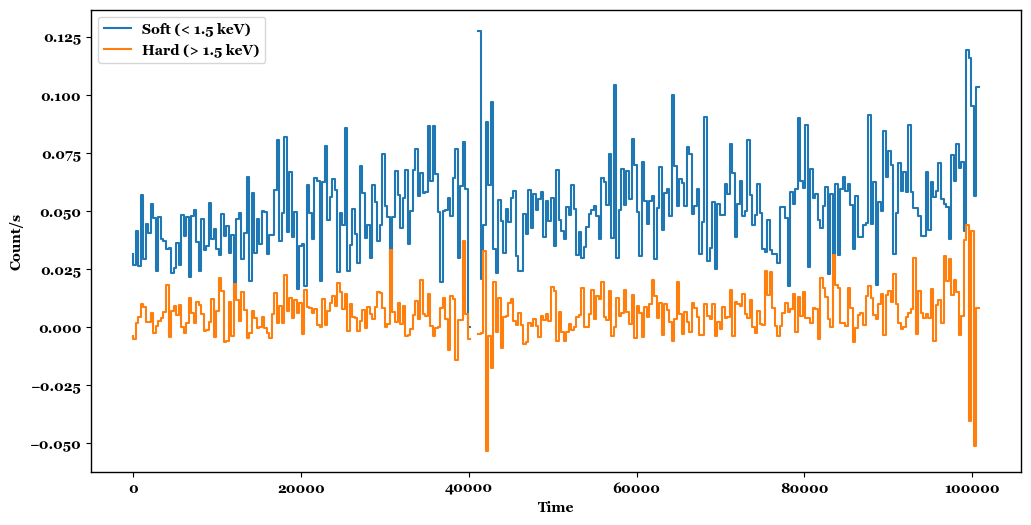

In [15]:
# Plot combined LC
hdul = fits.open('ABAur_combined_lc_soft.lc')
hdul.info()
lc_soft = Table(hdul[1].data)
x_soft = np.arange(hdul[1].header['TSTART'], hdul[1].header['TSTOP'], hdul[1].header['TIMEDEL'])-hdul[1].header['TSTART']

hdul = fits.open('ABAur_combined_lc_hard.lc')
hdul.info()
lc_hard = Table(hdul[1].data)
x_hard = np.arange(hdul[1].header['TSTART'], hdul[1].header['TSTOP'], hdul[1].header['TIMEDEL'])-hdul[1].header['TSTART']

plt.figure(figsize=(12,6))
plt.step(x_soft, np.sum(lc_soft['RATE'], 1), label='Soft (< 1.5 keV)')
plt.step(x_hard, np.sum(lc_hard['RATE'], 1), label='Hard (> 1.5 keV)')
plt.xlabel('Time')
plt.ylabel('Count/s')
plt.legend()
plt.show()

# Spectra Extraction - EMOS & EPN



Checking for Event Files...


File 2232_0671960101_EMOS1_S001_ImagingEvts.ds exists. 



Extracting source spectrum...


Executing: 
evselect table='2232_0671960101_EMOS1_S001_ImagingEvts.ds' keepfilteroutput='no' withfilteredset='no' filteredset='filtered.fits' destruct='yes' flagcolumn='EVFLAG' flagbit='-1' filtertype='expression' dssblock='' expression='#XMMEA_EMOS1&&(PATTERN<=12) && ((X,Y) IN circle(28736.144,26999.234,600))' writedss='yes' cleandss='no' updateexposure='yes' filterexposure='yes' blockstocopy='' attributestocopy='' energycolumn='PI' withzcolumn='no' zcolumn='WEIGHT' withzerrorcolumn='no' zerrorcolumn='EWEIGHT' ignorelegallimits='no' withimageset='no' imageset='image.fits' xcolumn='RAWX' ycolumn='RAWY' imagebinning='imageSize' ximagebinsize='1' yimagebinsize='1' squarepixels='no' ximagesize='600' yimagesize='600' withxranges='no' ximagemin='1' ximagemax='640' withyranges='no' yimagemin='1' yimagemax='640' withimagedatatype='no' imagedatatype='Real64' withcelestialc

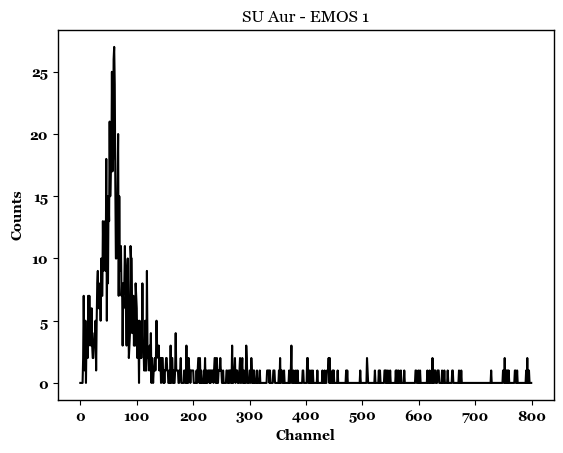

In [19]:
# SU Aur - EMOS 1

# Prepare
q_flag       = "#XMMEA_EMOS1" # Quality flag
n_pattern    = 12           # Pattern selection. Should be 12 for MOS detectors

spec_min      = 0
spec_max     = 11999
bin_size     = 15
region_1     = (28736.144, 26999.234)
radius       = 600
bkg_1        = (28736.144, 31000.5)
bkg_radius   = 1200
work_dir           = '/Users/woodml/Observing/XMM-Newton/AB_Aur/0671960101/'
event_file         = '2232_0671960101_EMOS1_S001_ImagingEvts.ds'
source_file        = 'ABAur_EMOS1_spec.fits'
bkg_file           = 'ABAur_EMOS1_bkg_spec.fits'
response_file      = 'EPIC_MOS1.rmf'
ancillary_file     = 'EPIC_MOS1.anc'
final_file         = 'ABAur_EMOS1_spec_final.fits'

# Extract
extract_spectrum(q_flag, n_pattern, bin_size, region_1, radius, bkg_1, bkg_radius, spec_min, spec_max,
                 work_dir, event_file, source_file, bkg_file, response_file, ancillary_file, final_file)

# Plot
plt.figure()
plot_spectrum('ABAur_EMOS1_spec_final.fits', c='k')
plt.xlabel('Channel')
plt.ylabel('Counts')
plt.title('SU Aur - EMOS 1')
plt.show()



Checking for Event Files...


File 2232_0671960101_EMOS2_S002_ImagingEvts.ds exists. 



Extracting source spectrum...


Executing: 
evselect table='2232_0671960101_EMOS2_S002_ImagingEvts.ds' keepfilteroutput='no' withfilteredset='no' filteredset='filtered.fits' destruct='yes' flagcolumn='EVFLAG' flagbit='-1' filtertype='expression' dssblock='' expression='#XMMEA_EMOS2&&(PATTERN<=12) && ((X,Y) IN circle(28747.581,26990.385,600))' writedss='yes' cleandss='no' updateexposure='yes' filterexposure='yes' blockstocopy='' attributestocopy='' energycolumn='PI' withzcolumn='no' zcolumn='WEIGHT' withzerrorcolumn='no' zerrorcolumn='EWEIGHT' ignorelegallimits='no' withimageset='no' imageset='image.fits' xcolumn='RAWX' ycolumn='RAWY' imagebinning='imageSize' ximagebinsize='1' yimagebinsize='1' squarepixels='no' ximagesize='600' yimagesize='600' withxranges='no' ximagemin='1' ximagemax='640' withyranges='no' yimagemin='1' yimagemax='640' withimagedatatype='no' imagedatatype='Real64' withcelestialc

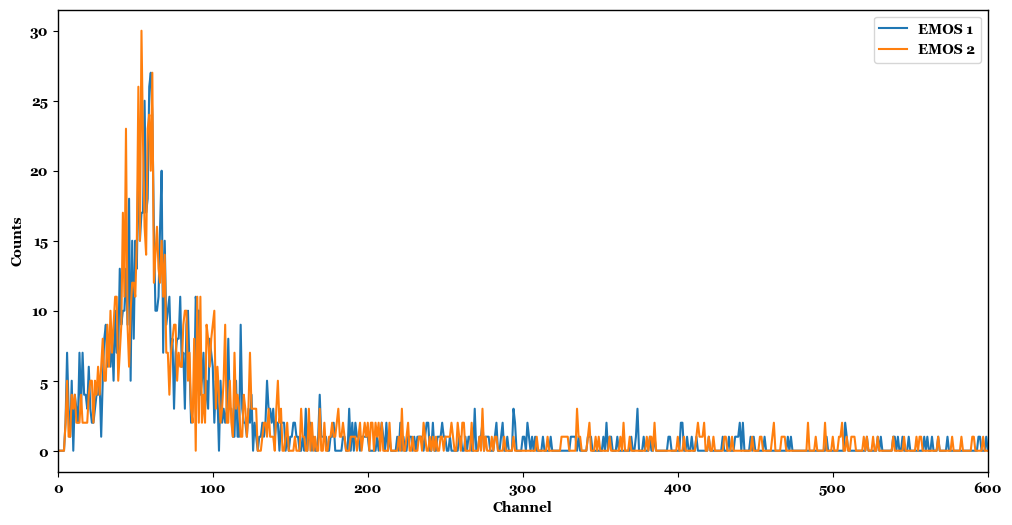

In [20]:
# Su Aur - EMOS 2

q_flag       = "#XMMEA_EMOS2" # Quality flag
n_pattern    = 12           # Pattern selection. Should be 12 for MOS detectors
region_2     = (28747.581, 26990.385)
radius       = 600
bkg_2        = (28747.581, 31000.5) 
bkg_radius   = 1200.
spec_min     = 0
spec_max     = 11999
bin_size     = 15

work_dir           = '/Users/woodml/Observing/XMM-Newton/AB_Aur/0671960101/'
event_file         = '2232_0671960101_EMOS2_S002_ImagingEvts.ds'
source_file        = 'ABAur_EMOS2_spec.fits'
bkg_file           = 'ABAur_EMOS2_bkg_spec.fits'
response_file      = 'EPIC_MOS2.rmf'
ancillary_file     = 'EPIC_MOS2.anc'
final_file         = 'ABAur_EMOS2_spec_final.fits'

extract_spectrum(q_flag, n_pattern, bin_size, region_2, radius, bkg_2, bkg_radius,spec_min,
                 spec_max, work_dir, event_file, source_file,bkg_file,response_file,ancillary_file, final_file)

plt.figure(figsize=(12,6))
plot_spectrum('ABAur_EMOS1_spec_final.fits', label='EMOS 1')
plot_spectrum('ABAur_EMOS2_spec_final.fits', label='EMOS 2')
plt.legend(loc='upper right')
plt.xlabel('Channel')
plt.ylabel('Counts')
plt.xlim(0,600)
plt.show()



Checking for Event Files...


File 2232_0671960101_EPN_S003_ImagingEvts.ds exists. 



Extracting source spectrum...


Executing: 
evselect table='2232_0671960101_EPN_S003_ImagingEvts.ds' keepfilteroutput='no' withfilteredset='no' filteredset='filtered.fits' destruct='yes' flagcolumn='EVFLAG' flagbit='-1' filtertype='expression' dssblock='' expression='#XMMEA_EP&&(PATTERN<=4) && ((X,Y) IN circle(28741.627,27041.752,600.0))' writedss='yes' cleandss='no' updateexposure='yes' filterexposure='yes' blockstocopy='' attributestocopy='' energycolumn='PI' withzcolumn='no' zcolumn='WEIGHT' withzerrorcolumn='no' zerrorcolumn='EWEIGHT' ignorelegallimits='no' withimageset='no' imageset='image.fits' xcolumn='RAWX' ycolumn='RAWY' imagebinning='imageSize' ximagebinsize='1' yimagebinsize='1' squarepixels='no' ximagesize='600' yimagesize='600' withxranges='no' ximagemin='1' ximagemax='640' withyranges='no' yimagemin='1' yimagemax='640' withimagedatatype='no' imagedatatype='Real64' withcelestialcenter=

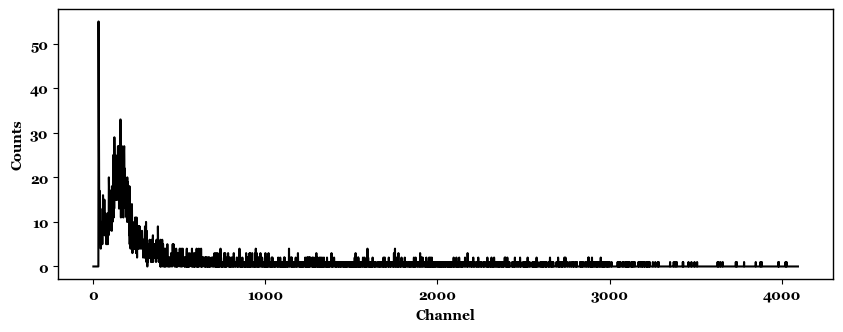

In [21]:
# SU Aur - EPN

# Prepare
q_flag       = "#XMMEA_EP"             # Quality flag
n_pattern    = 4                        # Pattern selection. Should be 12 for MOS detectors
region_pn   = (28741.627, 27041.752)
radius      = 600.
bkg_pn      = (28741.627, 24500.5)
bkg_radius  = 1200                    
spec_min     = 0
spec_max     = 20479
bin_size     = 5

work_dir           = '/Users/woodml/Observing/XMM-Newton/AB_Aur/0671960101/'
event_file         = '2232_0671960101_EPN_S003_ImagingEvts.ds'
source_file        = 'ABAur_EPN_spec.fits'
bkg_file           = 'ABAur_EPN_bkg_spec.fits'
response_file      = 'EPIC_PN.rmf'
ancillary_file     = 'EPIC_PN.anc'
final_file         = 'ABAur_EPN_spec_final.fits'

# Extract
extract_spectrum(q_flag, n_pattern, bin_size, region_pn, radius, bkg_pn, bkg_radius, spec_min, spec_max,
                 work_dir, event_file, source_file, bkg_file, response_file, ancillary_file, final_file)

# Plot
plt.figure(figsize=(10,3.5))
plot_spectrum('ABAur_EPN_spec_final.fits', c='k')
plt.xlabel('Channel')
plt.ylabel('Counts')
# plt.xlim(0,400)
plt.show()

In [22]:
# PLOT
plt.figure(figsize=(12,6))  # Size of figure
plot_spectrum('SUAur_EMOS1_final_spec_quiet.fits', label='quiescent')
plot_spectrum('SUAur_EMOS1_final_spec_flare.fits', label='flaring')
plt.title('SU Aur - EMOS 1')
plt.legend(loc='upper left')
plt.show()

# PLOT
plt.figure(figsize=(12,6))  # Size of figure
plot_spectrum('SUAur_EMOS2_final_spec_quiet.fits', label='quiescent')
plot_spectrum('SUAur_EMOS2_final_spec_flare.fits', label='flaring')
plt.title('SU Aur - EMOS 2')
plt.legend(loc='upper left')
plt.show()

# PLOT
plt.figure(figsize=(12,6))  # Size of figure
plot_spectrum('SUAur_EPN_final_spec_quiet.fits', label='quiescent')
plot_spectrum('SUAur_EPN_final_spec_flare.fits', label='flaring')
plt.title('SU Aur - EPN')
plt.legend(loc='upper left')
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'SUAur_EMOS1_final_spec_quiet.fits'

<Figure size 1200x600 with 0 Axes>

In [93]:
quiet = fits.open('SUAur_EMOS1_final_spec_quiet.fits')[1]
flare = fits.open('SUAur_EMOS1_final_spec_flare.fits')[1]

print(quiet.header)

print(Table(quiet.data))
print(Table(flare.data))

XTENSION= 'BINTABLE'           / binary table extension                         BITPIX  =                    8 / 8-bit bytes                                    NAXIS   =                    2 / 2-dimensional binary table                     NAXIS1  =                   10 / width of table in bytes                        NAXIS2  =                  800 / number of rows in table                        PCOUNT  =                    0 / size of special data area                      GCOUNT  =                    1 / one data group (required keyword)              TFIELDS =                    4 / number of fields in each row                   TTYPE1  = 'CHANNEL '           / The name of this column                        TFORM1  = 'I       '           / data format of field: 2-byte INTEGER           TTYPE2  = 'COUNTS  '           / The name of this column                        TFORM2  = 'J       '           / data format of field: 4-byte INTEGER           TUNIT2  = 'count   '           / physica

In [6]:
MJD = [12,21,23,430,230,1203]
n = 50000

In [10]:
%time RV = np.zeros((len(MJD), n))
print(len(RV), len(RV[0]))

CPU times: user 2.01 ms, sys: 2.37 ms, total: 4.38 ms
Wall time: 2.4 ms
6 50000


In [11]:
%time RV = [[0.0 for _ in range(len(MJD))] for _ in range(n)]
print(len(RV), len(RV[0]))

CPU times: user 99.2 ms, sys: 7.24 ms, total: 106 ms
Wall time: 105 ms
50000 6
